In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [3]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [4]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.202465,1.701719,-0.248340,0.728693,1.419708,1
1,0.579127,-1.136274,0.092358,2.989826,0.084391,0
2,2.115250,0.468151,1.733809,0.960207,0.804533,1
3,0.798168,-3.470230,1.097065,-1.751856,-1.261268,0
4,2.374967,0.827219,1.241384,0.009172,1.352587,1


In [5]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [6]:
import random

In [7]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [8]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [9]:
sample_rows(df,0.1)
# sample_features(df,0.5)

,col1,col2,col3,col4,col5,target
87,2.215071,2.118888,0.833098,0.186829,1.057585,1
56,-1.105724,-0.390578,1.126777,2.038240,-1.615800,0
47,-0.499482,1.624419,-1.121234,2.517767,0.287365,1
40,-2.039805,-1.887178,2.361132,-2.570594,-1.220747,0
70,-2.895083,0.066260,2.034808,0.671299,-2.049226,0
23,1.463427,0.865879,1.508458,0.873462,0.857951,1
50,-3.436038,0.922812,0.680907,1.753728,-1.168177,0
74,0.324903,-2.039385,-0.815778,1.495309,0.279934,0
84,1.316853,0.366967,1.731347,2.061717,0.278027,1
4,2.374967,0.827219,1.241384,0.009172,1.352587,1


In [10]:
df1 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_9637/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [11]:
df2 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_9637/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [12]:
df3 = combined_sampling(df,0.5,0.5)

/tmp/ipykernel_9637/3275485051.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


In [13]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col4', 'col1', 'target'], dtype='object')
Index(['col4', 'col2', 'target'], dtype='object')
Index(['col3', 'col5', 'target'], dtype='object')


In [14]:
df3

,col3,col5,target
26,0.581251,-0.965307,0
55,0.531616,-0.567611,0
46,1.926110,1.200843,1
6,2.586700,-1.971806,0
68,0.609246,-0.399140,1
9,0.567270,2.573357,1
83,-1.230060,1.213838,0
49,0.057664,0.542519,1
54,1.227069,-1.618491,0
74,-0.815778,0.279934,0


Using this combined sampling dataframes to train different classifier . we can train using row sampling, column sampling or like both that we are using 

In [15]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [16]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [17]:
from sklearn.tree import plot_tree

[Text(0.2857142857142857, 0.9285714285714286, 'x[1] <= -0.927\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.14285714285714285, 0.7857142857142857, 'gini = 0.0\nsamples = 14\nvalue = [14, 0]'),
 Text(0.21428571428571427, 0.8571428571428572, 'True  '),
 Text(0.42857142857142855, 0.7857142857142857, 'x[0] <= -0.485\ngini = 0.313\nsamples = 36\nvalue = [7, 29]'),
 Text(0.3571428571428571, 0.8571428571428572, '  False'),
 Text(0.2857142857142857, 0.6428571428571429, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5714285714285714, 0.6428571428571429, 'x[0] <= 1.711\ngini = 0.251\nsamples = 34\nvalue = [5, 29]'),
 Text(0.42857142857142855, 0.5, 'gini = 0.0\nsamples = 23\nvalue = [0, 23]'),
 Text(0.7142857142857143, 0.5, 'x[0] <= 2.309\ngini = 0.496\nsamples = 11\nvalue = [5, 6]'),
 Text(0.5714285714285714, 0.35714285714285715, 'x[0] <= 2.002\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.42857142857142855, 0.21428571428571427, 'gini = 0.0\nsamples = 4\nvalue = [4, 0

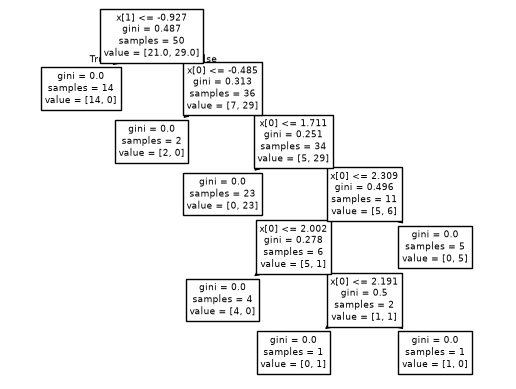

In [18]:
plot_tree(clf1)

[Text(0.4444444444444444, 0.9166666666666666, 'x[1] <= 0.81\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.3333333333333333, 0.75, 'x[0] <= 0.956\ngini = 0.36\nsamples = 34\nvalue = [26, 8]'),
 Text(0.38888888888888884, 0.8333333333333333, 'True  '),
 Text(0.2222222222222222, 0.5833333333333334, 'gini = 0.0\nsamples = 12\nvalue = [12, 0]'),
 Text(0.4444444444444444, 0.5833333333333334, 'x[0] <= 1.73\ngini = 0.463\nsamples = 22\nvalue = [14, 8]'),
 Text(0.2222222222222222, 0.4166666666666667, 'x[1] <= -0.787\ngini = 0.463\nsamples = 11\nvalue = [4, 7]'),
 Text(0.1111111111111111, 0.25, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.3333333333333333, 0.25, 'x[0] <= 1.155\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.2222222222222222, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.4444444444444444, 0.08333333333333333, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.6666666666666666, 0.4166666666666667, 'x[0] <= 2.511\ngini = 0.165\nsam

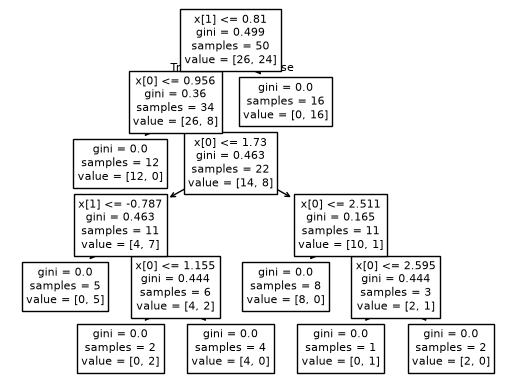

In [19]:
plot_tree(clf2)

[Text(0.5, 0.9, 'x[1] <= -0.413\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.3, 0.7, 'x[0] <= 0.399\ngini = 0.124\nsamples = 15\nvalue = [14, 1]'),
 Text(0.4, 0.8, 'True  '),
 Text(0.2, 0.5, 'x[0] <= 0.023\ngini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.1, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.3, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4, 0.5, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]'),
 Text(0.7, 0.7, 'x[0] <= -0.346\ngini = 0.353\nsamples = 35\nvalue = [8, 27]'),
 Text(0.6, 0.8, '  False'),
 Text(0.6, 0.5, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.8, 0.5, 'x[1] <= 0.815\ngini = 0.069\nsamples = 28\nvalue = [1, 27]'),
 Text(0.7, 0.3, 'x[1] <= 0.721\ngini = 0.142\nsamples = 13\nvalue = [1, 12]'),
 Text(0.6, 0.1, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.8, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.9, 0.3, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]')]

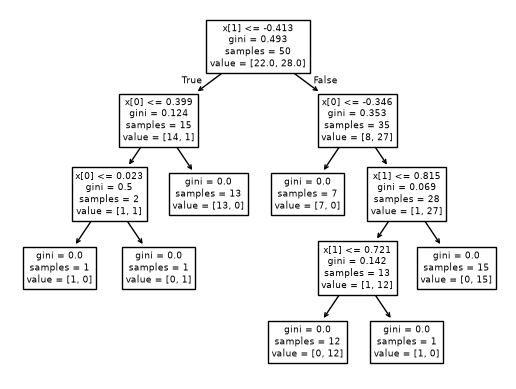

In [20]:
plot_tree(clf3)

we can see we are creating different tree due to bagging approach 

In [21]:
clf1.predict(np.array([-1.548743	,-0.387546]).reshape(1,2))

/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [22]:
clf2.predict(np.array([-1.548743	,-0.387546]).reshape(1,2))

/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [23]:
clf3.predict(np.array([-1.548743	,-0.387546]).reshape(1,2))

/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

So we will select 1 as all of our 3 classifier said it is 1 

In [26]:
# 1.809826	0.614932	0

print(clf1.predict(np.array([1.809826,	0.614932]).reshape(1,2)))
print(clf2.predict(np.array([1.809826,	0.614932]).reshape(1,2)))
print(clf3.predict(np.array([1.809826,	0.614932]).reshape(1,2)))


[0]
[0]
[1]


/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/foolmann/miniconda3/envs/ml312/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


As 2 out of 3 classifer is predicting 0 so class 0 is selected as per majority counting 

In [27]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
67,1.533036,-2.015524,0.694968,1.873118,-2.042002,0
59,-1.659313,0.189514,1.557163,2.552899,-2.377471,0
1,0.579127,-1.136274,0.092358,2.989826,0.084391,0
88,-0.771085,-3.009776,1.548109,1.274520,2.181855,1
31,-0.155662,0.344747,0.196504,0.905535,1.525269,1
92,1.594953,1.023918,1.986860,0.546140,1.137480,1
62,0.589929,2.330064,0.884252,1.067504,0.754031,1
52,-2.473756,0.510642,1.118706,2.440322,-0.045063,0
67,1.533036,-2.015524,0.694968,1.873118,-2.042002,0
5,-1.360475,-1.107315,1.786807,-0.058057,-2.420008,0
